# Paper figures

Reproduces every figure in the manuscript *Automated calculation of stationary
statistics for Itô stochastic differential equations*, one section per figure.
Each section is self-contained: it computes from the shipped models/simulators
and writes `figures/fig<N>_<name>.png` + `.pdf` (the exact files used in the
paper).

Conventions match the paper: white noise normalized as
$\langle\xi(t)\xi(t')\rangle = 2D\,\delta(t-t')$, so the linear
(Ornstein–Uhlenbeck) stationary variance is $C(0)=D/\mu$.

In [1]:
%matplotlib inline
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
# depth-robust repo root: walk up until the 'api' package is found
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'api')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
sys.path.insert(0, os.path.join(_root, 'notebooks'))
os.chdir(os.path.join(_root, 'notebooks'))   # cwd=notebooks/ for simulations/ paths
os.makedirs('figures', exist_ok=True)
import daedalus as dd

## Figure 1 — failures of the mean-field approximation (Section II)

**(a)** Quartic OU process $\partial_t\phi = -\mu\phi - \varepsilon\phi^3 + \xi$
($\mu = D = 1$, $\langle\xi\xi'\rangle = 2D\delta$): the autocovariance $C(\tau)$.
The linear (Gaussian) prediction $C(\tau)=(D/\mu)e^{-\mu|\tau|}$ matches the
simulation at $\varepsilon=0$; at $\varepsilon=0.06$ the cubic nonlinearity
suppresses the whole curve below it.

**(b)** Mutually exciting 2-neuron Hawkes process (delta synapses), stationary
mean spike rate. Parameters are chosen so the **linear** and **quadratic** theory
rates coincide (common dashed line). The linear transfer is exact
(theory $=$ simulation); the quadratic mean-field closure
$\langle v^2\rangle\to\langle v\rangle^2$ **undershoots** the simulation (Jensen),
the only bar to rise above the line.

In [2]:
# ── panel (a): OU quartic  C(tau) vs tau ─────────────────────────────────
from simulations.ou_langevin_sim_numba import sim_ou_quartic_numba

mu, D = float(1.0), float(1.0)
dt_sim, dt_bin = float(0.01), float(0.05)
T_sim, N_RUNS  = float(3.0e5), int(4)
n_steps = int(T_sim / dt_sim); bs = int(round(dt_bin / dt_sim)); n_bins = int(n_steps // bs)
tau_max = float(4.0); kmax = int(tau_max / dt_bin)
tau = np.arange(kmax + 1) * dt_bin

def acf_fft(x, kmax):                     # unbiased autocovariance C[k]=<x(t)x(t+k)>_c
    xc = np.asarray(x, float).ravel(); xc = xc - xc.mean()
    M = len(xc); n = 1
    while n < 2 * M: n *= 2
    f = np.fft.rfft(xc, n)
    a = np.fft.irfft(f * np.conj(f), n)[:kmax + 1]
    return a / (M - np.arange(kmax + 1))

_ = sim_ou_quartic_numba(int(1000), dt_sim, mu, float(0.05), D, float(0.0), bs, int(100), int(0))  # JIT
def sim_ctau(eps):
    acc = np.zeros(kmax + 1)
    for r in range(N_RUNS):
        xb = sim_ou_quartic_numba(n_steps, dt_sim, mu, float(eps), D, float(0.0), bs, n_bins, int(200 + r))
        acc += acf_fft(xb, kmax)
    return acc / N_RUNS

C_theory = (D / mu) * np.exp(-mu * tau)   # linear/Gaussian autocovariance
C_sim0   = sim_ctau(0.0)
C_sim6   = sim_ctau(0.06)
print('OU  C(0):  linear=%.3f   sim(eps=0)=%.3f   sim(eps=0.06)=%.3f'
      % (C_theory[0], C_sim0[0], C_sim6[0]))

OU  C(0):  linear=1.000   sim(eps=0)=0.988   sim(eps=0.06)=0.860


In [3]:
# ── panel (b): 2-neuron Hawkes, mean rate — bars: linear vs quadratic ─────
from simulations.hawkes_sim_multipop_numba import (
    sim_hawkes_multipop_numba, sim_hawkes_multipop_quad_numba)

Em   = np.array([0.35, 0.35])             # baseline drive
tauv = np.array([0.5, 0.5])               # membrane time constant
taug = np.full((2, 2), 0.04)              # delta (instantaneous) synapse
W0   = np.array([[0.25, 0.25], [0.20, 0.30]])
s    = float(0.7)
Ws   = np.ascontiguousarray(s * W0)
aq   = float(0.6)                         # quadratic gain (from parameter scan)

def mf_quad_rate(a):                      # <v> = E + sWA<v>^2 fixed point; rate_1 = a<v_1>^2
    v = Em.copy()
    for _ in range(4000):
        v = 0.6 * v + 0.4 * (Em + Ws @ (a * v * v))
    return float(a * v[0] * v[0])
def lin_rate_theory(a):                   # exact linear rate of neuron 1  (I - sWA)^-1
    v = np.linalg.solve(np.eye(2) - Ws @ np.diag([a, a]), Em)
    return float(a * v[0])
def sim_rate(kind, a, seeds=range(20, 30)):
    dt, T = float(0.004), float(3.0e5); ns = int(T / dt); bs2 = int(50); nb = int(ns // bs2)
    av = np.array([a, a])
    f = sim_hawkes_multipop_numba if kind == 'lin' else sim_hawkes_multipop_quad_numba
    rr = [float(np.asarray(f(ns, dt, tauv, av, Em, Ws, taug, Em.copy(), bs2, nb, int(sd))[2], float)[0] / T)
          for sd in seeds]
    rr = np.array(rr); return float(rr.mean()), float(rr.std(ddof=1) / np.sqrt(len(rr)))

quad_th = mf_quad_rate(aq)
quad_sim, quad_err = sim_rate('quad', aq)
lo, hi = 1e-3, 2.5                         # solve a_lin so linear theory == quad theory
for _ in range(60):
    mid = 0.5 * (lo + hi)
    if lin_rate_theory(mid) < quad_th: lo = mid
    else: hi = mid
a_lin = 0.5 * (lo + hi)
lin_th = lin_rate_theory(a_lin)
lin_sim, lin_err = sim_rate('lin', a_lin)
print('a_lin = %.4f' % a_lin)
print('linear   : theory=%.4f  sim=%.4f  (exact)' % (lin_th, lin_sim))
print('quadratic: theory=%.4f  sim=%.4f  (gap %+.1f%%, %.0f sigma)'
      % (quad_th, quad_sim, 100 * (quad_sim - quad_th) / quad_sim, (quad_sim - quad_th) / quad_err))

a_lin = 0.2282
linear   : theory=0.0868  sim=0.0867  (exact)
quadratic: theory=0.0868  sim=0.0919  (gap +5.5%, 25 sigma)


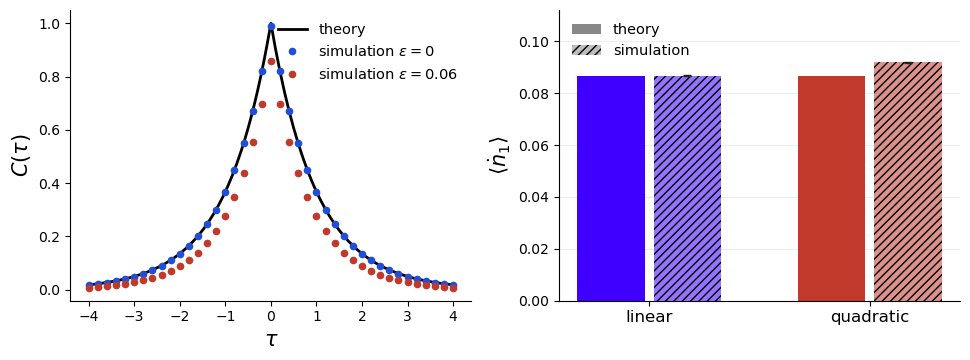

saved figures/fig1_moment_closure.{png,pdf}


In [4]:
# ── assemble Figure 1 ────────────────────────────────────────────────────────
# NB: numeric literals wrapped in float() — the sage kernel preparses bare
# decimals to RealLiteral, which the matplotlib PDF backend cannot serialize.
f = float
fig, (axa, axb) = plt.subplots(1, 2, figsize=(f(9.8), f(3.7)))

# panel (a): C(tau), mirrored to negative tau. Symmetric marker sampling
# guarantees a point exactly at tau=0.
tf  = np.concatenate([-tau[::-1], tau[1:]])
mir = lambda C: np.concatenate([C[::-1], C[1:]])
c0  = len(tau) - 1                                  # index of tau=0 in tf
ks  = np.arange(0, len(tau), 4)                     # one-sided strides (includes 0)
mi  = np.unique(np.concatenate([c0 - ks, c0 + ks]))  # symmetric, tau=0 included
axa.plot(tf, mir(C_theory), '-', lw=f(2.0), color='black', label='theory')
axa.plot(tf[mi], mir(C_sim0)[mi], 'o', ms=f(4.5), color='#1f4fd8', label=r'simulation $\varepsilon=0$')
axa.plot(tf[mi], mir(C_sim6)[mi], 'o', ms=f(4.5), color='#C0392B', label=r'simulation $\varepsilon=0.06$')
axa.set_xlabel(r'$\tau$', fontsize=f(15)); axa.set_ylabel(r'$C(\tau)$', fontsize=f(15))
axa.legend(fontsize=f(10.5), frameon=False)
axa.spines['top'].set_visible(False); axa.spines['right'].set_visible(False)

# panel (b): 4 grouped bars, neuron n_1 rate only. Cast every layout number.
xt, xs, gL, gQ, BW, AL = f(0.0), f(0.9), f(0.0), f(2.6), f(0.8), f(0.55)
qth, qsim, qerr = f(quad_th), f(quad_sim), f(quad_err)
lth, lsim, lerr = f(lin_th), f(lin_sim), f(lin_err)
axb.bar(gL + xt, lth,  BW, color='#3F00FF', zorder=2)
axb.bar(gL + xs, lsim, BW, color='#3F00FF', hatch='////', alpha=AL, zorder=2, yerr=lerr, capsize=3, ecolor='#222')
axb.bar(gQ + xt, qth,  BW, color='#C0392B', zorder=2)
axb.bar(gQ + xs, qsim, BW, color='#C0392B', hatch='////', alpha=AL, zorder=2, yerr=qerr, capsize=3, ecolor='#222')
axb.set_xticks([gL + (xt + xs) / 2.0, gQ + (xt + xs) / 2.0])
axb.set_xticklabels(['linear', 'quadratic'], fontsize=f(12))
axb.set_ylabel(r'$\langle \dot n_1\rangle$', fontsize=f(15))
from matplotlib.patches import Patch
axb.legend(handles=[Patch(facecolor='#888', label='theory'),
                    Patch(facecolor='#888', hatch='////', alpha=AL, label='simulation')],
           fontsize=f(10.5), frameon=False, loc='upper left')
axb.set_ylim(f(0.0), qsim * f(1.22)); axb.grid(alpha=f(0.22), axis='y')
axb.spines['top'].set_visible(False); axb.spines['right'].set_visible(False)

fig.tight_layout()
fig.savefig('figures/fig1_moment_closure.png', dpi=int(200), bbox_inches='tight')
fig.savefig('figures/fig1_moment_closure.pdf', bbox_inches='tight')
plt.show()
print('saved figures/fig1_moment_closure.{png,pdf}')